In [1]:
import warnings
warnings.filterwarnings(action='ignore') 

import csv
import folium
import matplotlib.pyplot as plt
plt.rc('font',family='D2CodingLigature Nerd Font')

In [2]:
f1 = open('../../data/LOCAL_PEOPLE_DONG_202510.csv', encoding='utf8')
data = csv.reader(f1)
next(data)
data = list(data)
print(len(data))  

315456


In [3]:
print(data[0])

['20251001', '00', '11110515', '14561.0577', '588.3189', '374.8785', '459.9435', '387.2249', '431.7462', '432.571', '458.5653', '489.3383', '661.5676', '555.6315', '482.4606', '378.0271', '215.7855', '599.4907', '696.5016', '417.3243', '474.932', '323.8609', '376.0797', '458.6009', '644.8304', '703.2934', '750.6172', '692.1842', '607.2663', '504.9111', '362.0048', '1033.1016', '']


In [4]:
f2 = open('../../data/dong_code.csv', encoding='utf8')
code_data = csv.reader(f2)

In [5]:
next(code_data)
next(code_data)
code_data = list(code_data)  # list형태로 변환

In [6]:
print(len(code_data))

424


In [7]:
print(code_data[0])

['1101053', '11110530', '서울', '종로구', '사직동']


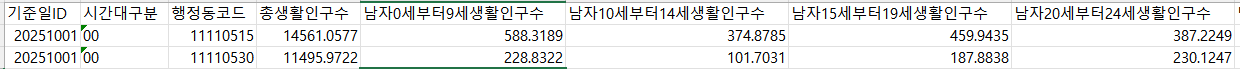

In [8]:
##  data 각 항목의 데이터 타입을 숫자 형태로 변경
## 날짜, 시간, 행정동코드, ...

for row in data:
    for i in range(1, 32):
        if i<=2:
            row[i] = int(row[i])
        else:
            row[i] = float(row[i])
            

In [9]:
print(data[0])

['20251001', 0, 11110515, 14561.0577, 588.3189, 374.8785, 459.9435, 387.2249, 431.7462, 432.571, 458.5653, 489.3383, 661.5676, 555.6315, 482.4606, 378.0271, 215.7855, 599.4907, 696.5016, 417.3243, 474.932, 323.8609, 376.0797, 458.6009, 644.8304, 703.2934, 750.6172, 692.1842, 607.2663, 504.9111, 362.0048, 1033.1016, '']


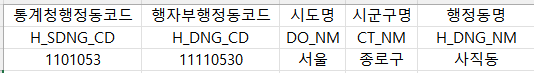

In [10]:
##  code_data 행정동코드 항목의 데이터 타입을 숫자 형태로 변경

print(code_data[0])

for row in code_data:
    #print(row)
    row[1] = int(row[1]) # 행자부 행정 동코드만 정수형으로 변환


['1101053', '11110530', '서울', '종로구', '사직동']


In [11]:
## 입력한 동의 행정동코드를 code_data에서 찾아오기

dong_name = input("행정동 입력 :")
print(dong_name)


행정동 입력 : 사직동


사직동


In [12]:
dong_code = False

for r in code_data:
    if r[-1] == dong_name:
        dong_code = r[1]
        break

if dong_code:
    print(f"{dong_name}의 행정도코드는 {dong_code}입니다.")
else:
    print(f"{dong_name}에 해당하는 코드를 찾을 수 없습니다.")

사직동의 행정도코드는 11110530입니다.


In [13]:
## 원하는 동의 2025년 10월 평균 생활 인구 수

s = 0

for r in data:
    if r[2] == dong_code:
        s += r[3]

print(f"{dong_name}의 10월 평균 생활인구수 : {s/30/24:,.2f}명")



사직동의 10월 평균 생활인구수 : 24,745.75명


In [14]:
## 입력한 동의 0시 시간대 생활인구 평균

s0 = 0
s1 = 0

for row in data:
    if row[2] == dong_code and row[1]==0:
        s0 += row[3]
    elif row[2]==dong_code and row[1]==1:
        s1 += row[3]

print(f"{dong_name}의 10월 0시 평균 생활인구수 : {s0/31}명")
print(f"{dong_name}의 10월 1시 평균 생활인구수 : {s0/31}명")

사직동의 10월 0시 평균 생활인구수 : 11207.645096774193명
사직동의 10월 1시 평균 생활인구수 : 11207.645096774193명


In [15]:
##  입력한 동의 0~23시 각 시간대 별 생활인구 평균

s = [0 for i in range(24)]
print(s)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


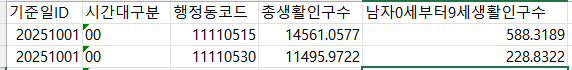

In [16]:
for row in data:
    if row[2] == dong_code:
        s[row[1]] = s[row[1]] + row[3]

s = [j/31  for j in s]

print(s)

[11207.645096774193, 11008.67042903226, 10942.02222580645, 10933.828261290324, 11130.156258064517, 11778.300822580646, 13644.622399999997, 17474.392974193546, 25762.46798064516, 30819.569280645155, 33546.93578387097, 37141.792067741924, 39105.17290645162, 39369.80273548388, 39169.14173548387, 38444.57834516127, 36803.79150967743, 34742.599164516134, 29603.08997419355, 25137.275816129033, 21857.18769032259, 18267.164441935485, 15305.953048387093, 11543.900999999998]


findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont

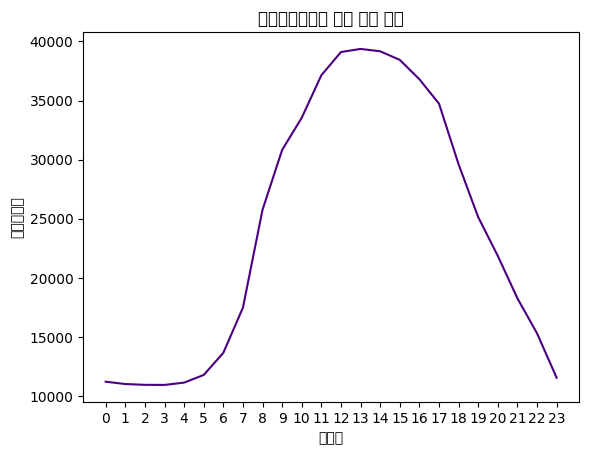

In [18]:
plt.title(dong_name + '시간대별 평균 생활 인구')
plt.plot(range(24), s, color='indigo')
plt.xticks(range(24))
plt.xlabel('시간대')
plt.ylabel('평균인구수')
plt.show()


In [19]:
dong_name1 = input("첫번째 행정동 입력 : ") # 이촌1동
dong_name2 = input("두번째 행정동 입력 : ") # 소공동

print(dong_name1)
print(dong_name2)

첫번째 행정동 입력 :  사직동
두번째 행정동 입력 :  삼청동


사직동
삼청동


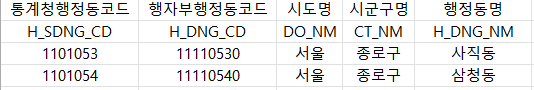

In [25]:
dong_code1 = False
dong_code2 = False

for r in code_data:
    
    if r[-1] == dong_name1:
        dong_code1 = r[1]
    if r[-1] == dong_name2:
        dong_code2 = r[1]

In [26]:
print(dong_code1)

11110530


In [27]:
if dong_code1:
    print(f"{dong_name1}의 행정동 코드는 {dong_code1}입니다.")
else:
    print(f"{dong_name1}에 해당하는 코드를 찾을 수 없습니다.")

if dong_code2:
    print(f"{dong_name2}의 행정동 코드는 {dong_code2}입니다.")
else:
    print(f"{dong_name2}에 해당하는 코드를 찾을 수 없습니다.")

사직동의 행정동 코드는 11110530입니다.
삼청동의 행정동 코드는 11110540입니다.


In [32]:
s1 = [0 for i in range(24)]
s2 = [0 for i in range(24)]

print(f"s1 = {s1}")
print(f"s2 = {s2}")

s1 = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
s2 = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


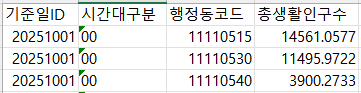

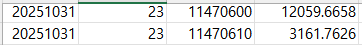

In [33]:
for row in data:
    # 첫 번째 행정동의 시간대별 인구수 총합 구하기
    if row[2] == dong_code1:
        s1[row[1]] += row[3]

    # 두 번째 행정동의 시간대별 인구수 총합 구하기

    elif row[2] == dong_code2:
        s2[row[1]] += row[3]

In [34]:
s1 = [p/31 for p in s1]
s2 = [p/31 for p in s2]

print(s1)
print(s2)

[11207.645096774193, 11008.67042903226, 10942.02222580645, 10933.828261290324, 11130.156258064517, 11778.300822580646, 13644.622399999997, 17474.392974193546, 25762.46798064516, 30819.569280645155, 33546.93578387097, 37141.792067741924, 39105.17290645162, 39369.80273548388, 39169.14173548387, 38444.57834516127, 36803.79150967743, 34742.599164516134, 29603.08997419355, 25137.275816129033, 21857.18769032259, 18267.164441935485, 15305.953048387093, 11543.900999999998]
[3717.4155612903232, 3735.72930967742, 3747.9475870967744, 3763.2107612903224, 3850.1431709677413, 3922.526661290323, 4245.246403225807, 5311.832916129032, 6191.1928, 7267.241216129033, 8415.526722580646, 9775.437348387097, 10727.28615483871, 11155.28861612903, 11345.604238709677, 10969.6291483871, 9975.934887096771, 8662.55444516129, 6869.450438709676, 5673.466154838711, 4859.788741935483, 4224.703264516129, 3922.466464516129, 3811.3567967741938]


findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont: Font family 'D2CodingLigature Nerd Font' not found.
findfont

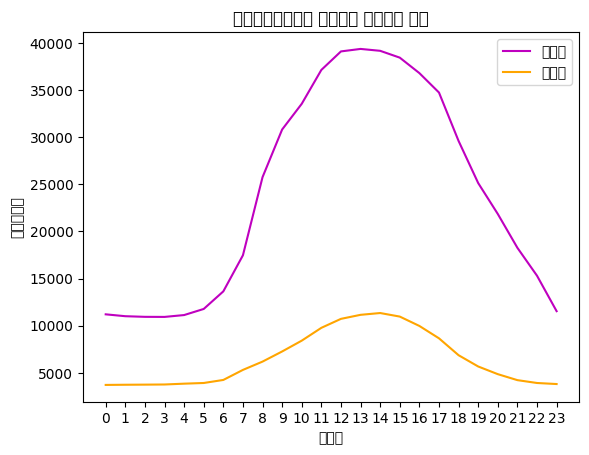

In [36]:
plt.title(dong_name1 + '과' + dong_name2 + '의 시간대별 평균인구 비교')
plt.plot(range(24), s1, color='m', label=dong_name1)
plt.plot(range(24), s2, color='orange', label=dong_name2)
plt.legend()
plt.xlabel('시간대')
plt.ylabel('평균인구수')
plt.xticks(range(24), range(24))
plt.grid(False)
plt.show()